In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install shap

In [3]:
pip install lightgbm pandas scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# ========== Load Data ==========
train_path = r"C:\Users\Aswathi M\Downloads\combined_train.csv"
test_path = r"C:\Users\Aswathi M\Downloads\combined_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ========== Preprocessing ==========
# Keep only numeric columns
train_df = train_df.select_dtypes(include=[np.number])
test_df = test_df.select_dtypes(include=[np.number])

# Show label distribution
print("Train label distribution:\n", train_df['label'].value_counts())
print("\nTest label distribution:\n", test_df['label'].value_counts())

# Split features and labels
X_train_full = train_df.drop('label', axis=1)
y_train_full = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# Normalize data
scaler = StandardScaler()
X_train_full = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ========== Simulated Federated Learning ==========
n_clients = 3
client_data = []
X_splits = np.array_split(X_train_full, n_clients)
y_splits = np.array_split(y_train_full, n_clients)

for i in range(n_clients):
    client_data.append((X_splits[i], y_splits[i]))

# Global validation set (simulate a secure central location)
X_val, _, y_val, _ = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# ========== Train Local Models ==========
client_predictions = []
params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 4,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1
}

for i, (X_client, y_client) in enumerate(client_data):
    print(f"\nTraining model for client {i+1}...")
    train_data = lgb.Dataset(X_client, label=y_client)
    model = lgb.train(params, train_data, num_boost_round=100)
    preds = model.predict(X_val)
    client_predictions.append(preds)

# ========== Aggregate Predictions ==========
avg_preds = np.mean(client_predictions, axis=0)
y_pred = np.argmax(avg_preds, axis=1)

# ========== Evaluate ==========
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nAccuracy Score:", accuracy_score(y_val, y_pred))


Train label distribution:
 label
0    5000
1    5000
2    5000
3    5000
Name: count, dtype: int64

Test label distribution:
 label
0    1500
1    1500
2    1500
3    1500
Name: count, dtype: int64

Training model for client 1...

Training model for client 2...

Training model for client 3...

Confusion Matrix:
 [[608   0   1 116]
 [  1 741   4   0]
 [  0   0 782   0]
 [196  73   2 476]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.84      0.79       725
           1       0.91      0.99      0.95       746
           2       0.99      1.00      1.00       782
           3       0.80      0.64      0.71       747

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.86      3000
weighted avg       0.87      0.87      0.86      3000


Accuracy Score: 0.869


In [28]:
import shap
import matplotlib.pyplot as plt

# Use the saved model from client 1
explainer = shap.TreeExplainer(client1_model)

# Compute SHAP values for the validation set
shap_values = explainer.shap_values(X_val)

# Plot SHAP summary (bar chart of most important features)
shap.summary_plot(shap_values, X_val, plot_type="bar", class_names=[0, 1, 2, 3])


NameError: name 'client1_model' is not defined

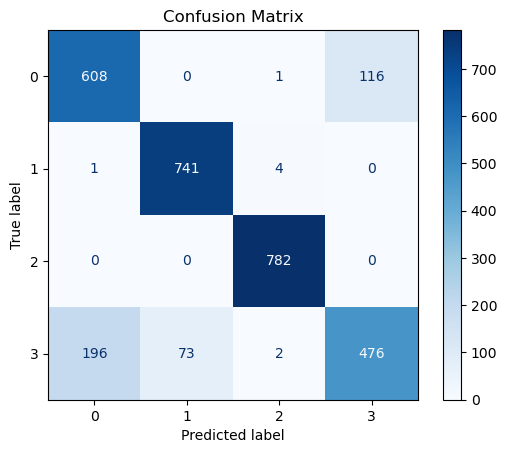

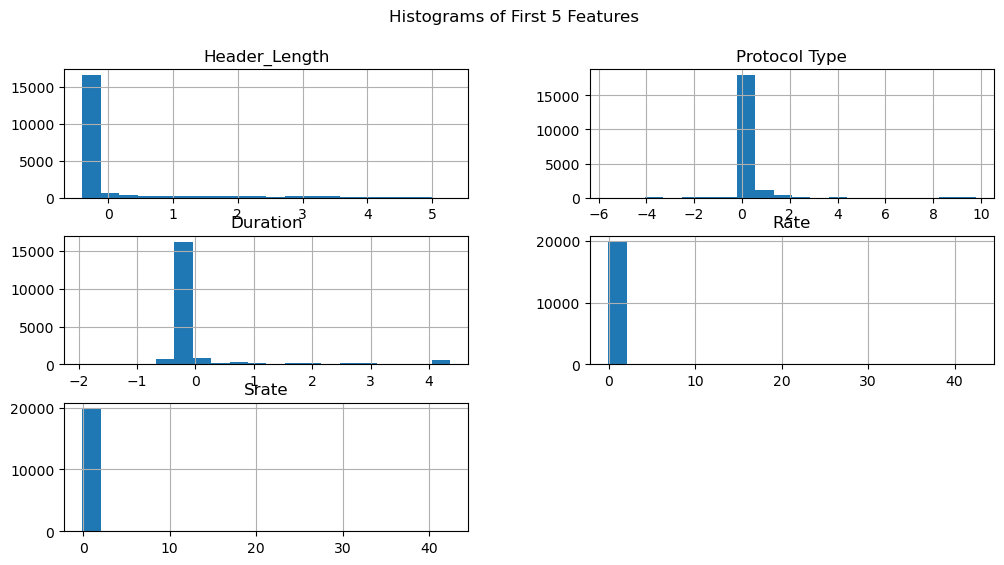

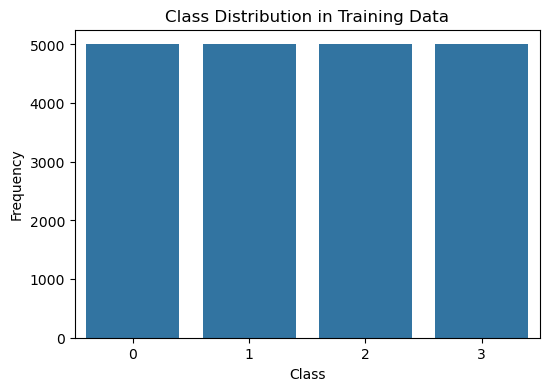

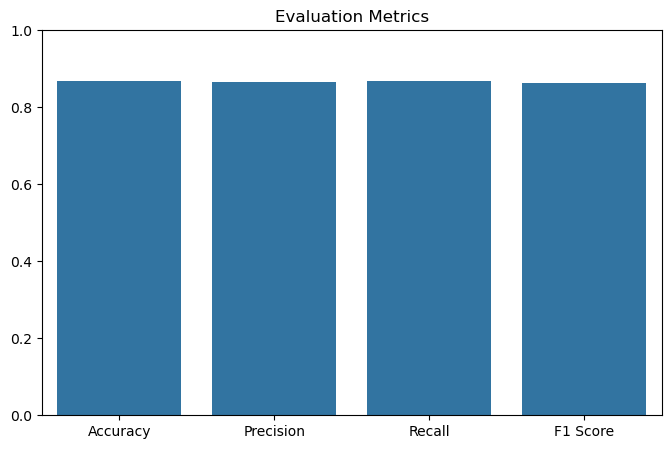

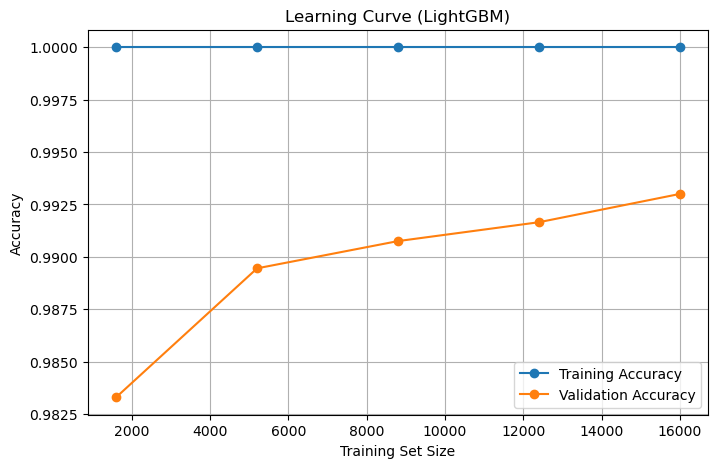

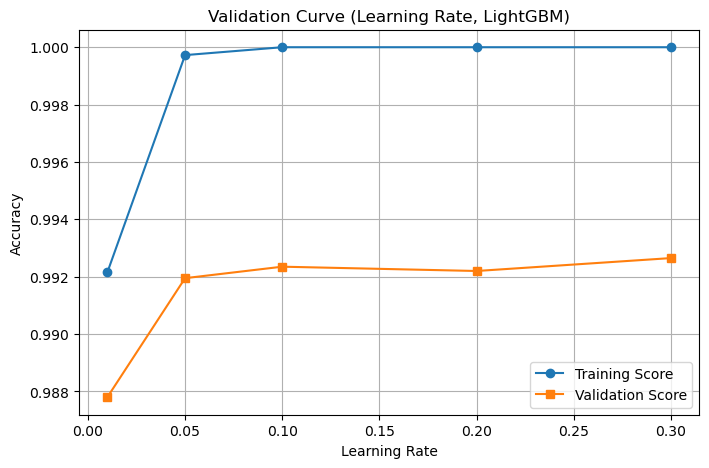

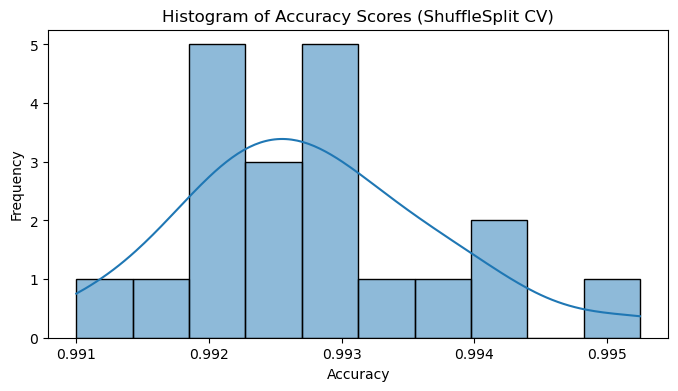

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ShuffleSplit, learning_curve, validation_curve
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from lightgbm import LGBMClassifier
import numpy as np

# --- 1. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# --- 2. Histogram of First Few Features ---
X_train_full.iloc[:, :5].hist(bins=20, figsize=(12, 6))
plt.suptitle("Histograms of First 5 Features")
plt.show()

# --- 3. Bar Chart: Label Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_full)
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

# --- 4. Evaluation Metric Bar Graph ---
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

plt.figure(figsize=(8, 5))
metrics = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
sns.barplot(x=labels, y=metrics)
plt.ylim(0, 1)
plt.title("Evaluation Metrics")
plt.show()

# --- 5. Learning Curve using LGBMClassifier ---
clf = LGBMClassifier(objective='multiclass', num_class=4)
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    clf, X_train_full, y_train_full, cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Accuracy')
plt.plot(train_sizes, val_mean, 'o-', label='Validation Accuracy')
plt.title("Learning Curve (LightGBM)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --- 6. Validation Curve (learning_rate) ---
param_range = [0.01, 0.05, 0.1, 0.2, 0.3]
train_scores, val_scores = validation_curve(
    LGBMClassifier(objective='multiclass', num_class=4),
    X_train_full, y_train_full,
    param_name="learning_rate", param_range=param_range,
    scoring="accuracy", cv=3
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, label="Training Score", marker='o')
plt.plot(param_range, val_mean, label="Validation Score", marker='s')
plt.title("Validation Curve (Learning Rate, LightGBM)")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --- 7. ShuffleSplit Histogram of Accuracy ---
cv = ShuffleSplit(n_splits=20, test_size=0.2, random_state=42)
scores = []

for train_idx, test_idx in cv.split(X_train_full):
    clf = LGBMClassifier(objective='multiclass', num_class=4)
    clf.fit(X_train_full.iloc[train_idx], y_train_full.iloc[train_idx])
    y_pred_cv = clf.predict(X_train_full.iloc[test_idx])
    scores.append(accuracy_score(y_train_full.iloc[test_idx], y_pred_cv))

plt.figure(figsize=(8, 4))
sns.histplot(scores, bins=10, kde=True)
plt.title("Histogram of Accuracy Scores (ShuffleSplit CV)")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()
